In [1]:
import json
import folium
import osmnx as ox
import networkx as nx
import random
import matplotlib.pyplot as plt
from IPython.display import display


# Section 1: Shortest Path Debugging - Resolve why bridge bike traffic does not show in heat map

1. Extract smaller map on a more simple area - maisonneuve st.
2. Evaluate if shortest_path works on any randomly sampled two nodes 

![Maissonneuve St. Snippet](images/Screenshot%202026-06-15%20at%209.07.21 PM.png)

In [1]:
bounding_box = [-73.574243, 45.505084, -73.568235, 45.502279]
G = ox.graph.graph_from_bbox(bounding_box, network_type="bike")
G_undirected = G.to_undirected()


NameError: name 'ox' is not defined

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_22431/3106704690.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


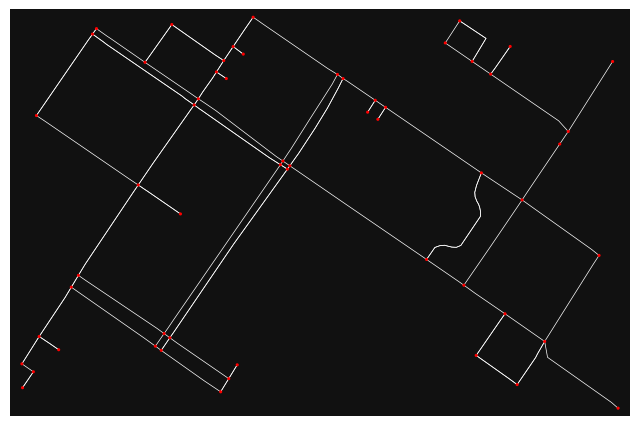

In [ ]:
fig, ax = ox.plot.plot_graph(G, node_size=5, node_color="red", edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
fig.show()

Although the map appears to be all connected, if looking at it directionally, there would be 13 disconnected components.

In [ ]:
print(nx.number_weakly_connected_components(G))  
print(nx.number_strongly_connected_components(G)) 

1
13


In [ ]:
# uncomment for randomly sampling nodes
# node1, node2 = random.sample(list(G_undirected.nodes()), 2)
# print(node1, node2)

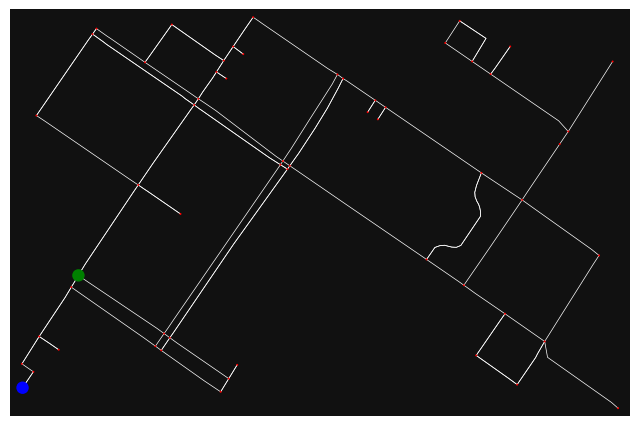

In [ ]:
node1 = 29793834
node2 = 11701999907

node_colors = []
node_sizes = []
for node in G.nodes():
    if node == node1:
        node_colors.append("green")
        node_sizes.append(80)
    elif node == node2:
        node_colors.append("blue")
        node_sizes.append(80)
    else:
        node_colors.append("red")
        node_sizes.append(2)

fig, ax = ox.plot.plot_graph(G, node_color=node_colors, node_size=node_sizes, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
display(fig)
plt.close()


### Failed Case: ox.graph.graph_from_bbox(bounding_box, network_type="bike") results in directed graph
Fails on (node1 = 29793834, node2 = 11701999907)

In [ ]:
# Debug: check connectivity between node1 and node2 in directed graph
components = list(nx.strongly_connected_components(G))
print(f"Number of strongly connected components: {len(components)}")

comp_of = {}
for i, comp in enumerate(components):
    for n in comp:
        comp_of[n] = i

print(f"node1 ({node1}) is in component {comp_of[node1]} (size {len(components[comp_of[node1]])})")
print(f"node2 ({node2}) is in component {comp_of[node2]} (size {len(components[comp_of[node2]])})")
print(f"Same component: {comp_of[node1] == comp_of[node2]}")


Number of strongly connected components: 13
node1 (29793834) is in component 8 (size 39)
node2 (11701999907) is in component 12 (size 2)
Same component: False


In [ ]:
try:
    path = nx.shortest_path(G, node1, node2, weight="length")
except nx.NetworkXNoPath as e:
    print(e)

No path between 29793834 and 11701999907.


### Succeeds on G.toundirected() undirected graph
Disadvantage: however this loses the directional representation of the bike lanes

In [ ]:
path = nx.shortest_path(G_undirected, node1, node2, weight="length")

In [ ]:
# Debug: check connectivity between node1 and node2
components = list(nx.connected_components(G_undirected))
print(f"Number of connected components: {len(components)}")

comp_of = {}
for i, comp in enumerate(components):
    for n in comp:
        comp_of[n] = i

print(f"node1 ({node1}) is in component {comp_of[node1]} (size {len(components[comp_of[node1]])})")
print(f"node2 ({node2}) is in component {comp_of[node2]} (size {len(components[comp_of[node2]])})")
print(f"Same component: {comp_of[node1] == comp_of[node2]}")


Number of connected components: 1
node1 (29793834) is in component 0 (size 57)
node2 (11701999907) is in component 0 (size 57)
Same component: True


[29793834, 208773296, 11119130926, 208765395, 11329849241, 11701999907]


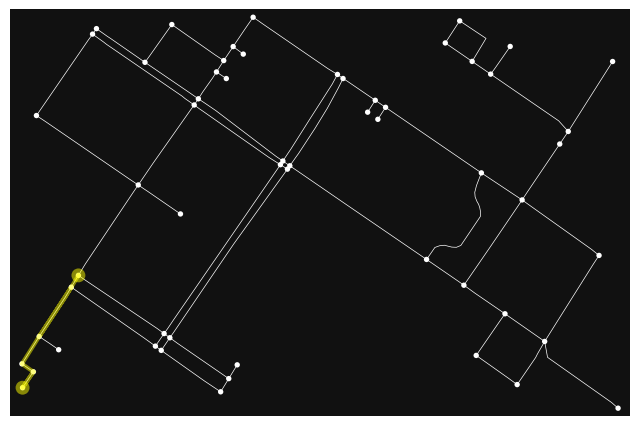

In [ ]:
path = nx.shortest_path(G_undirected, node1, node2, weight="length")
print(path)

fig, ax = ox.plot.plot_graph_route(G_undirected, path, node_size=15, edge_color="#FFFFFF", edge_linewidth=0.5, route_color="yellow", route_linewidth=3, show=False)
display(fig)
plt.close()


# Section 2: Now we try to debug the Jacques Cartier Bridge directly
![Jacques Cartier Bridge](images/Screenshot%202026-06-15%20at%209.14.58 PM.png)

In [12]:
bounding_box_2 = [-73.55596, 45.53335, -73.50789, 45.51092]
G_2 = ox.graph.graph_from_bbox(bounding_box_2, network_type="bike")
G_2_undirected = G_2.to_undirected()

### Bike graph appears to be missing a bunch of roads

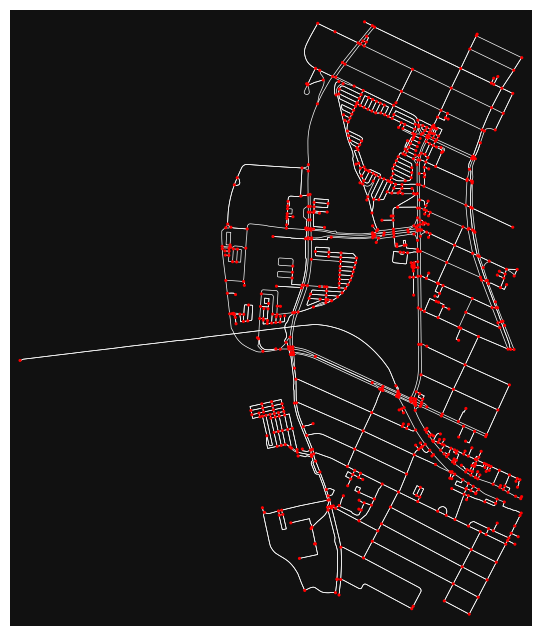

In [13]:
fig, ax = ox.plot.plot_graph(G_2, node_size=5, node_color="red", edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
display(fig)
plt.close()

### All network road with the same bounding box

In [14]:
G_2 = ox.graph.graph_from_bbox(bounding_box_2, network_type="all")
G_2_undirected = G_2.to_undirected()

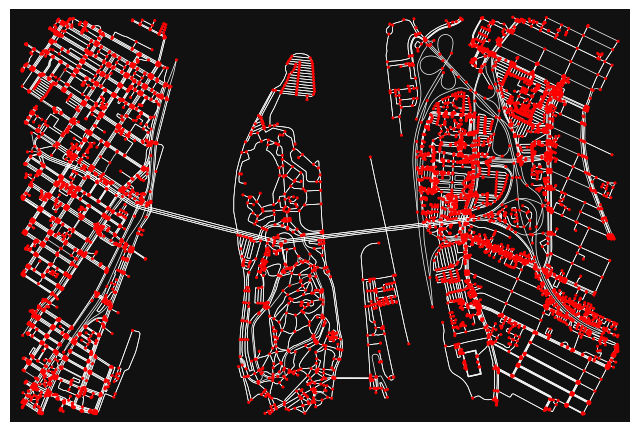

In [15]:
fig, ax = ox.plot.plot_graph(G_2, node_size=5, node_color="red", edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
display(fig)
plt.close()

### Combination of Walkable + Bikable network
From Google Search:
We forgot that cyclist and pedestrians can sometimes share routes.

![Google Search Result for Bridge](images/Screenshot%202026-06-15%20at%209.23.58 PM.png)

In [16]:
G_bike = ox.graph.graph_from_bbox(bounding_box_2, network_type="bike")
G_walk = ox.graph.graph_from_bbox(bounding_box_2, network_type="walk")
G_2 = nx.compose(G_bike, G_walk)
G_2_undirected = G_2.to_undirected()

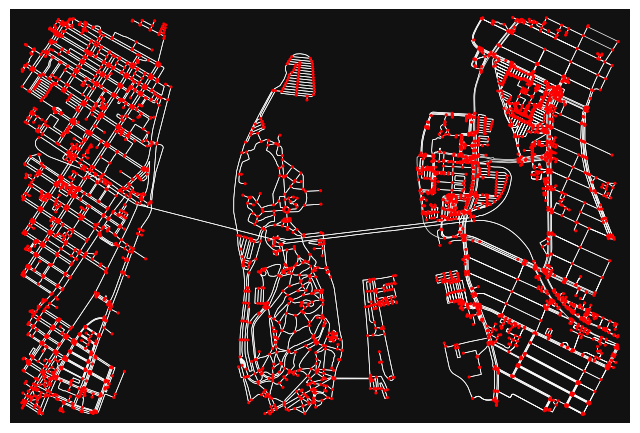

In [17]:
fig, ax = ox.plot.plot_graph(G_2, node_size=5, node_color="red", edge_color="#FFFFFF", edge_linewidth=0.5, show=False)
display(fig)
plt.close()

In [18]:
print(nx.number_weakly_connected_components(G_2))
print(nx.number_strongly_connected_components(G_2))

1
4


11212226569 13928623476


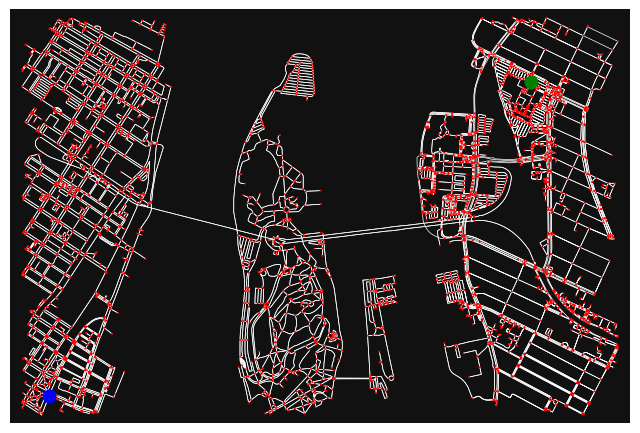

In [19]:
# uncomment for randomly sampling nodes
# node1, node2 = random.sample(list(G_2_undirected.nodes()), 2)
# print(node1, node2)

node1 = list(G_2.nodes())[0]
node2 = list(G_2.nodes())[-1]
print(node1, node2)

fig, ax = ox.plot.plot_graph(G_2, node_color="red", node_size=2, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)

for node, color in [(node1, "green"), (node2, "blue")]:
    x = G_2.nodes[node]["x"]
    y = G_2.nodes[node]["y"]
    ax.scatter(x, y, c=color, s=80, zorder=10)

display(fig)
plt.close()


### Result with Directed Graph

In [20]:
# Debug: check connectivity between node1 and node2 in directed graph
components = list(nx.strongly_connected_components(G_2))
print(f"Number of strongly connected components: {len(components)}")

comp_of = {}
for i, comp in enumerate(components):
    for n in comp:
        comp_of[n] = i

print(f"node1 ({node1}) is in component {comp_of[node1]} (size {len(components[comp_of[node1]])})")
print(f"node2 ({node2}) is in component {comp_of[node2]} (size {len(components[comp_of[node2]])})")
print(f"Same component: {comp_of[node1] == comp_of[node2]}")


Number of strongly connected components: 4
node1 (11212226569) is in component 2 (size 4211)
node2 (13928623476) is in component 2 (size 4211)
Same component: True


In [21]:
path = nx.shortest_path(G_2, node1, node2, weight="length")

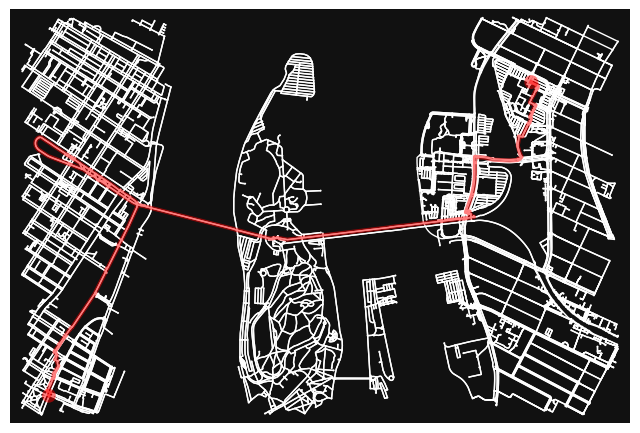

In [22]:
fig, ax = ox.plot.plot_graph_route(G_2, path, node_size=2, edge_color="#FFFFFF", edge_linewidth=1, route_color="red", route_linewidth=3, show=False)
display(fig)
plt.close()


### Result with undirected graph

In [23]:
# Debug: check connectivity between node1 and node2 in undirected graph
components = list(nx.connected_components(G_2_undirected))
print(f"Number of connected components: {len(components)}")

comp_of = {}
for i, comp in enumerate(components):
    for n in comp:
        comp_of[n] = i

print(f"node1 ({node1}) is in component {comp_of[node1]} (size {len(components[comp_of[node1]])})")
print(f"node2 ({node2}) is in component {comp_of[node2]} (size {len(components[comp_of[node2]])})")
print(f"Same component: {comp_of[node1] == comp_of[node2]}")


Number of connected components: 1
node1 (11212226569) is in component 0 (size 4214)
node2 (13928623476) is in component 0 (size 4214)
Same component: True


[11212226569, 11212226555, 11212226614, 11212226615, 11212226756, 11214433594, 11214433611, 11214433564, 11214433597, 11214439844, 11214433598, 11212593899, 11212226732, 11212226734, 11212226746, 11212226745, 11212226662, 11214433562, 11212226663, 11215432756, 11212226723, 11212226664, 11212226519, 11212226511, 6736802104, 3430323953, 11200795382, 11200795378, 11200795433, 11200795432, 324267506, 5077332487, 1924490853, 12895125843, 11196831051, 11196836072, 6491244159, 6491244165, 6491237134, 6491237141, 6491237137, 11198279114, 445238688, 11198279103, 11198279101, 5266912870, 6339765418, 5667438530, 13186940742, 11538204521, 11538204524, 6412791354, 11537687194, 11537687196, 6412791346, 11541714193, 11541714197, 11541714195, 6802263135, 11537217871, 11537217873, 6802263138, 11541714106, 11541714108, 13113406343, 11538204546, 11541714204, 11541714200, 11541714203, 13113406347, 13113406346, 11538217492, 11537217859, 11537217857, 11538204559, 11538204564, 11538217471, 11538217480, 10994

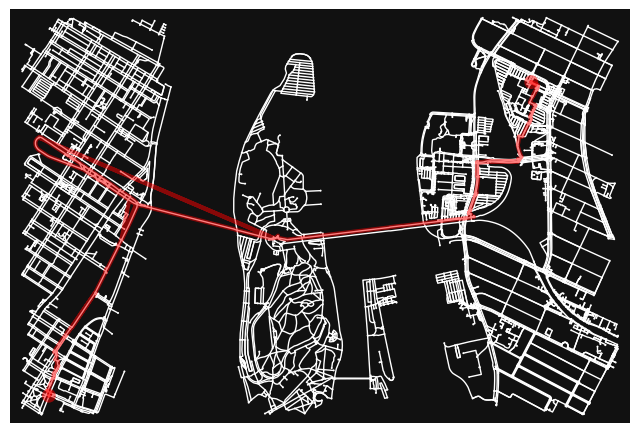

In [24]:
# preserve edge geometry lost during to_undirected() conversion
for u, v, data in G_2.edges(data=True):
    if "geometry" in data and G_2_undirected.has_edge(u, v):
        G_2_undirected[u][v][0]["geometry"] = data["geometry"]

path = nx.shortest_path(G_2_undirected, node1, node2, weight="length")
print(path)

fig, ax = ox.plot.plot_graph_route(G_2_undirected, path, node_size=2, edge_color="#FFFFFF", edge_linewidth=1, route_color="red", route_linewidth=3, show=False)
display(fig)
plt.close()


Here, directed graph appears to be more properly representing. 

We will turn back to the maisonneuve case to evaluate directed graph for Bike + Walk

# Section 3: Re-test Section 1 nodes with Bike + Walk directed graph
Testing nodes (29793834, 11701999907) that previously failed on the directed bike-only graph.

In [25]:
G_bike_s1 = ox.graph.graph_from_bbox(bounding_box, network_type="bike")
G_walk_s1 = ox.graph.graph_from_bbox(bounding_box, network_type="walk")
G_s1 = nx.compose(G_bike_s1, G_walk_s1)

print(nx.number_weakly_connected_components(G_s1))
print(nx.number_strongly_connected_components(G_s1))


1
5


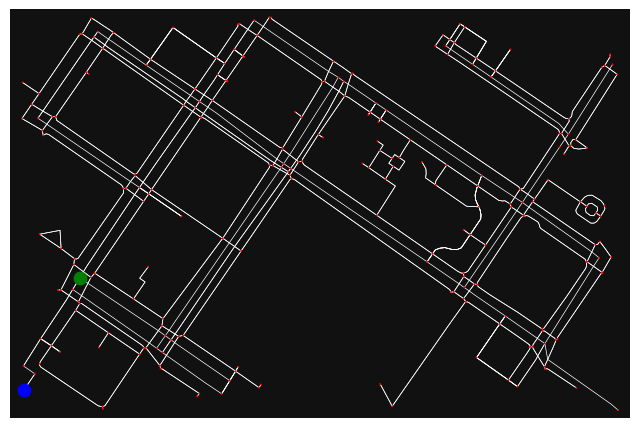

In [26]:
node1 = 29793834
node2 = 11701999907

fig, ax = ox.plot.plot_graph(G_s1, node_color="red", node_size=2, edge_color="#FFFFFF", edge_linewidth=0.5, show=False)

for node, color in [(node1, "green"), (node2, "blue")]:
    x = G_s1.nodes[node]["x"]
    y = G_s1.nodes[node]["y"]
    ax.scatter(x, y, c=color, s=80, zorder=10)

display(fig)
plt.close()


In [27]:
# Debug: check connectivity in directed bike+walk graph
components = list(nx.strongly_connected_components(G_s1))
print(f"Number of strongly connected components: {len(components)}")

comp_of = {}
for i, comp in enumerate(components):
    for n in comp:
        comp_of[n] = i

print(f"node1 ({node1}) is in component {comp_of[node1]} (size {len(components[comp_of[node1]])})")
print(f"node2 ({node2}) is in component {comp_of[node2]} (size {len(components[comp_of[node2]])})")
print(f"Same component: {comp_of[node1] == comp_of[node2]}")


Number of strongly connected components: 5
node1 (29793834) is in component 3 (size 224)
node2 (11701999907) is in component 4 (size 2)
Same component: False


In [28]:
try:
    path = nx.shortest_path(G_s1, node1, node2, weight="length")
    print(path)
    fig, ax = ox.plot.plot_graph_route(G_s1, path, node_size=2, edge_color="#FFFFFF", edge_linewidth=0.5, route_color="yellow", route_linewidth=3, show=False)
    display(fig)
    plt.close()
except nx.NetworkXNoPath as e:
    print(e)


No path between 29793834 and 11701999907.


Directed maisonneuve graph still doesn't work well

### Now, looking back. plot_graph_route plots straight line between nodes, losing geometry, attempting geometry fix

[11212226569, 11212226555, 11212226614, 11212226615, 11212226756, 11214433594, 11214433611, 11214433564, 11214433597, 11214439844, 11214433598, 11212593899, 11212226732, 11212226734, 11212226746, 11212226745, 11212226662, 11214433562, 11212226663, 11215432756, 11212226723, 11212226664, 11212226519, 11212226511, 6736802104, 3430323953, 11200795382, 11200795378, 11200795433, 11200795432, 324267506, 5077332487, 1924490853, 12895125843, 11196831051, 11196836072, 6491244159, 6491244165, 6491237134, 6491237141, 6491237137, 11198279114, 445238688, 11198279103, 11198279101, 5266912870, 6339765418, 5667438530, 13186940742, 11538204521, 11538204524, 6412791354, 11537687194, 11537687196, 6412791346, 11541714193, 11541714197, 11541714195, 6802263135, 11537217871, 11537217873, 6802263138, 11541714106, 11541714108, 13113406343, 11538204546, 11541714204, 11541714200, 11541714203, 13113406347, 13113406346, 11538217492, 11537217859, 11537217857, 11538204559, 11538204564, 11538217471, 11538217480, 10994

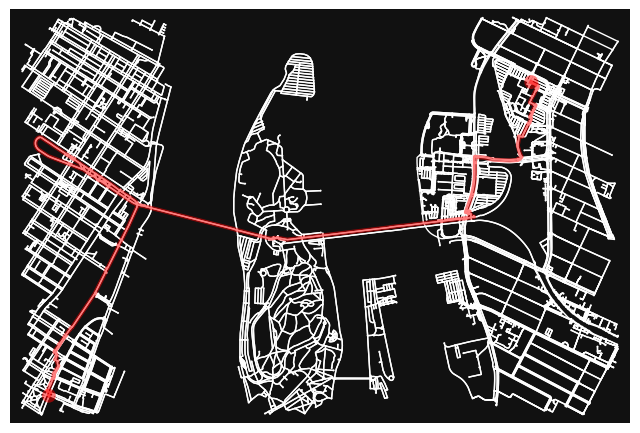

In [ ]:
node1 = list(G_2.nodes())[0]
node2 = list(G_2.nodes())[-1]
# preserve edge geometry lost during to_undirected() conversion
for u, v, data in G_2.edges(data=True):
    if "geometry" in data and G_2_undirected.has_edge(u, v):
        G_2_undirected[u][v][0]["geometry"] = data["geometry"]

path = nx.shortest_path(G_2_undirected, node1, node2, weight="length")
print(path)

# path = nx.shortest_path(G_2, node1, node2, weight="length")
# print(path)

fig, ax = ox.plot.plot_graph_route(G_2_undirected, path, node_size=2, edge_color="#FFFFFF", edge_linewidth=1, route_color="red", route_linewidth=3, show=False)
display(fig)
plt.close()

### Conclusion: both approaches has caveats
- Directed graph contains inaccurate road directions and limits the routes
- Undirected graph loses edge shape and result in routes not fitting to roads.